/tmp/ipykernel_193908/2337906827.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


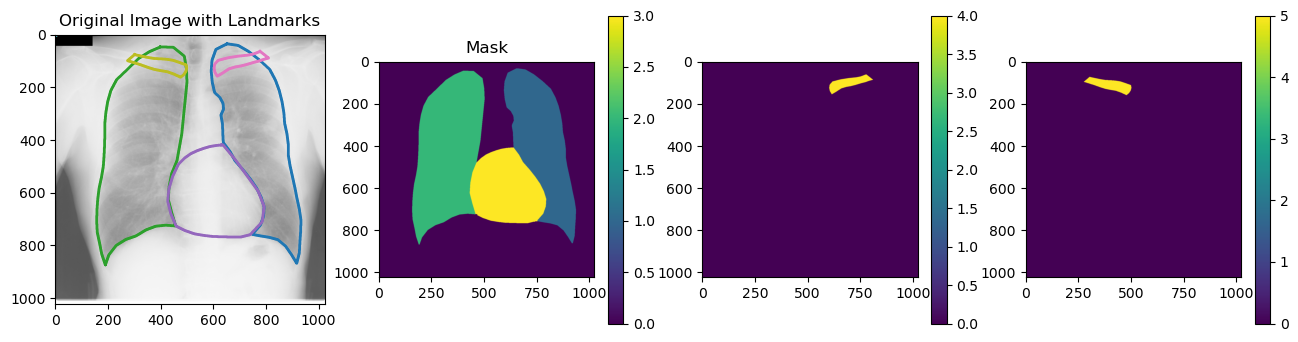

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import json
import pandas as pd
import networkx as nx
from collections import defaultdict
import os

image_list_path = Path("../Dataset/CXRAY/Landmarks_3_10") / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path("../Dataset/CXRAY/Landmarks_3_10") / 'images' / image_list[736]
landmarks_path = Path("../Dataset/CXRAY/Landmarks_3_10") / 'landmarks' / image_list[736].replace('.png', '.json')

image = cv2.imread(str(image_path))

landmarks = json.load(open(landmarks_path, 'r'))

# As there is no mask for the image, we will create one based on the landmarks

mask = np.zeros(image.shape[:2] + tuple([6]), dtype=np.uint8)
i = 1
for contour in landmarks.values():
    aux = np.zeros(image.shape[:2], dtype=np.uint8)
    aux = cv2.drawContours(aux, [np.array(contour)], -1, 1, thickness=cv2.FILLED)
    mask[:,:,i] = aux
    i+= 1

# A little post-processing to make the organs joints more smooth

mask[:,:,3] = cv2.dilate(mask[:,:,3], np.ones((5, 5), np.uint8), iterations=4)
mask[:,:,3][(mask[:,:,1] > 0) | (mask[:,:,2] > 0)] = 0

mask[726:,:740,3] = cv2.erode(mask[726:,:740,3], np.ones((5, 5), np.uint8), iterations=4)
mask[760:,740:,3] = 0

for i in range(1,4):
    mask[:,:,i] = cv2.morphologyEx(mask[:,:,i], cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    mask[:,:,i] = cv2.morphologyEx(mask[:,:,i], cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

original_mask = mask.copy()

# The mask is now ready, but we need to split it into independent organs

# First set is right lung, left lung and heart
mask_1 = mask.copy()[:,:,(0,1,2,3)]
# Second independent set is the left clavicle
mask_2 = mask.copy()[:,:,(0,4)]
# Third independent set is the right clavicle
mask_3 = mask.copy()[:,:,(0,5)]

# Then we argmax to convert the masks to single channel
mask_1 = mask_1.argmax(axis=2)

mask_2 = mask_2.argmax(axis=2)
mask_2[mask_2 > 0] += 3

mask_3 = mask_3.argmax(axis=2)
mask_3[mask_3 > 0] += 4  

masks = [mask_1, mask_2, mask_3]

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)
plt.title('Original Image with Landmarks')

plt.subplot(1, 4, 2)
plt.imshow(mask_1)
plt.colorbar()
plt.title('Mask')

plt.subplot(1, 4, 3)
plt.imshow(mask_2)
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(mask_3)
plt.colorbar()


In [3]:
from utils.unified_graph_utils import build_unified_contour_graph, create_unified_adjacency_matrix

# Main code

all_graphs = []

for mask in masks:
    G = build_unified_contour_graph(mask)    
    all_graphs.append(G)
    
# Combine all graphs into a single unified graph
# These are disjoint graphs, so we cannot use nx.compose directly
G = nx.Graph()
for graph in all_graphs:
    G = nx.disjoint_union(G, graph)

# Create the unified adjacency matrix
unified_adj_matrix, organ_membership = create_unified_adjacency_matrix(G)

# Print statistics
print(f"Unified adjacency matrix shape: {unified_adj_matrix.shape}")
print(f"Total nodes in graph: {G.number_of_nodes()}")

# Count shared nodes
shared_nodes = sum(1 for node in G.nodes() if len(G.nodes[node]['organs']) > 1)
print(f"Number of shared boundary points: {shared_nodes}")

# Count nodes per organ
organ_counts = defaultdict(int)
for node in G.nodes():
    for org in G.nodes[node]['organs']:
        organ_counts[org] += 1

print("\nNodes per organ:")
for org, count in organ_counts.items():
    print(f"Organ {org}: {count} nodes")

Processing organ ID: 1
Processing organ ID: 2
Processing organ ID: 3
Processing organ ID: 4
Processing organ ID: 5
Unified adjacency matrix shape: (2558, 2558)
Total nodes in graph: 2558
Number of shared boundary points: 298

Nodes per organ:
Organ 1: 914 nodes
Organ 3: 534 nodes
Organ 2: 949 nodes
Organ 4: 223 nodes
Organ 5: 236 nodes


Drawing contours for organ 1 with 1813 points
Drawing contours for organ 2 with 1883 points
Drawing contours for organ 3 with 1050 points
Drawing contours for organ 4 with 426 points
Drawing contours for organ 5 with 456 points


Unique organ memberships: {'1-3', '4', '5', '2-3', '1', '2', '3'}


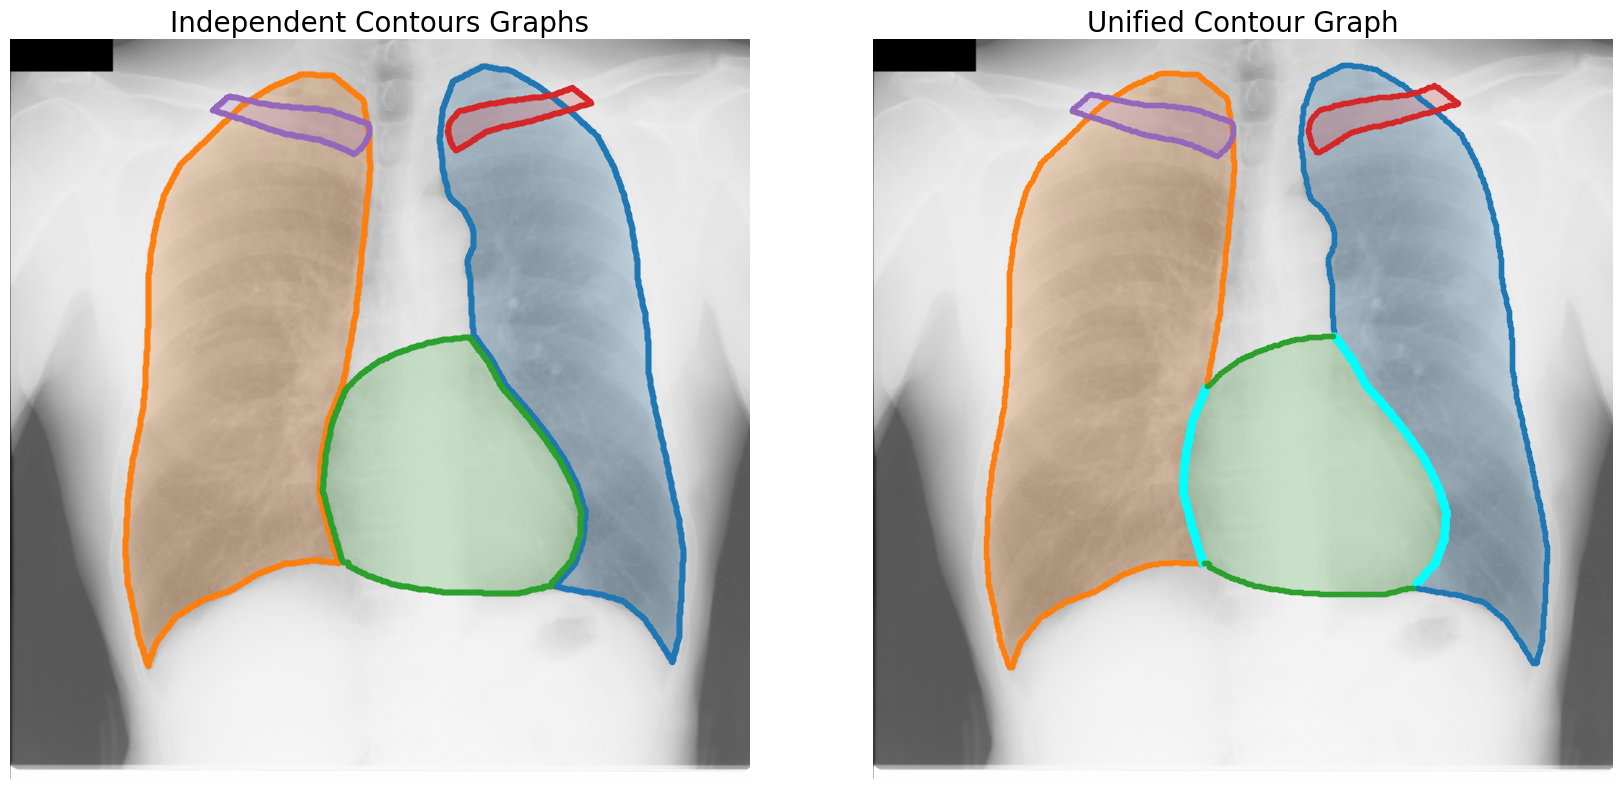

In [4]:
# Visualize the graph colored by organ membership
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')

# for each mask, draw the original contours
for m in range(1, original_mask.shape[2]):
    mask = original_mask[:, :, m]
    mask = (mask > 0).astype('uint8')
    # erode the mask to avoid overlapping contours
    mask = cv2.erode(mask, np.ones((5, 5), np.uint8), iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = np.array(contours[0], dtype=np.float32)
    print(f"Drawing contours for organ {m} with {len(contours)} points")
    
    if m == 1:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='tab:blue')
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:blue')
    elif m == 2:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='tab:orange')
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:orange')
    elif m == 3:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='tab:green')
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:green')
    elif m == 4:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='tab:red')
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:red')
    elif m == 5:
        plt.plot(contours[:, 0, 0], contours[:, 0, 1], 'o', markersize=3, label=f'Organ {m}', color='tab:purple')
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:purple')


plt.title('Independent Contours Graphs', fontsize=20)
plt.axis('off')
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.imshow(image, cmap='gray')
pos = nx.get_node_attributes(G, 'pos')

# Draw edges
for u, v in G.edges():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    plt.plot([x1, x2], [y1, y2], color='gray', linewidth=0.5, alpha=0.5)

# Draw nodes
for node in G.nodes():
    x, y = pos[node]
    organs = G.nodes[node]['organs']
    if len(organs) > 1:
        plt.plot(x, y, 'o', color="aqua", markersize=5)  # Shared nodes in deeppink
    else:
        # Color based on organ ID
        organ_id = organs[0]
        if organ_id == 1:
            color = 'tab:blue'
        elif organ_id == 2:
            color = 'tab:orange'
        elif organ_id == 3:
            color = 'tab:green'
        elif organ_id == 4:
            color = 'tab:red'
        elif organ_id == 5:
            color = 'tab:purple'
        plt.plot(x, y, 'o', color=color, markersize=3)

for m in range(1, original_mask.shape[2]):
    mask = original_mask[:, :, m]
    mask = (mask > 0).astype('uint8')
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = np.array(contours[0], dtype=np.float32)
    
    if m == 1:
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:blue')
    elif m == 2:
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:orange')
    elif m == 3:
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:green')
    elif m == 4:
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:red')
    elif m == 5:
        plt.fill(contours[:, 0, 0], contours[:, 0, 1], alpha=0.2, color='tab:purple')

plt.title('Unified Contour Graph', fontsize=20)
plt.axis('off')
plt.tight_layout()

plt.savefig("../Dataset/CXRAY/Landmarks_3_10/contour_graphs.png", dpi=300, bbox_inches='tight')

# print the unique node memberships
unique_memberships = set(organ_membership)
print(f"Unique organ memberships: {unique_memberships}")

In [5]:
from utils.unified_graph_utils import downsample_one_step, generate_edge_info, save_matrices

def generate_multi_organ_matrices(G, organ_membership, output_path, config, image):
    """
    Generate all matrices needed for multi-organ contour model,
    with naming conventions matching the original code
    """
    # Set node attributes for organ membership
    for i, node in enumerate(G.nodes()):
        G.nodes[node]['organ_membership'] = organ_membership[i]
    
    # Get unique organ IDs
    all_organs = set()
    for membership in organ_membership:
        for org in membership.split('-'):
            if org:  # Skip empty strings
                all_organs.add(org)
    organ_ids = sorted(list(all_organs))
    
    # Determine resolution sizes
    num_resolutions = len(config['resolutions'])
    
    # Resolution sizes need to be 16 at minimum, then grow by factor of 2
    desired_sizes = [16 * (2 ** i) for i in range(num_resolutions)]
    print(f"Desired resolution sizes: {desired_sizes}")

    # Create directories
    os.makedirs(output_path, exist_ok=True)
    
    # Initialize collections, starting with first resolution size
    
    # Number of nodes 
    print(f"Initial graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    while G.number_of_nodes() > (16 * (2 ** (num_resolutions)) * len(config['organs'])):
        G, _, _, _ = downsample_one_step(G)
    print(f"Graph at new full resolution: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    graphs = [G]  
    downsampling_matrices = {}
    upsampling_matrices = {}
    
    # Process each resolution
    for i in range(num_resolutions - 1):
        curr_graph = graphs[i]
        curr_res = config['resolutions'][i]
        next_res = config['resolutions'][i+1]
        
        # Downsample to target size
        G_down, _, D, U = downsample_one_step(curr_graph)
        
        # Store results
        graphs.append(G_down)
        downsampling_matrices[f"to_{next_res}"] = D
        upsampling_matrices[f"to_{curr_res}"] = U
    
    # Save the atlas image and positions for pretraining
    pos = nx.get_node_attributes(graphs[0], 'pos')
    pos = pd.DataFrame(pos).T
    pos = pos.to_numpy()
    pos_path = Path(config['output_path']) / 'atlas_pos.npy'
    np.save(pos_path, pos)
    image_path = Path(config['output_path']) / 'atlas_image.png'
    cv2.imwrite(str(image_path), image)
        
    # Save matrices in compatible format
    for i, graph in enumerate(graphs):
        res = config['resolutions'][i]
        save_matrices(graph, res, config, organ_ids)
    
    # Save downsampling and upsampling matrices
    for key, matrix in downsampling_matrices.items():
        np.save(f"{output_path}/downsampling_{key}.npy", matrix)
    
    for key, matrix in upsampling_matrices.items():
        np.save(f"{output_path}/upsampling_{key}.npy", matrix)
    
    # Generate edge information for all resolutions
    generate_edge_info(config)
            
    return graphs, downsampling_matrices, upsampling_matrices

In [6]:
# Define configuration
config = {
    "output_path": "../Dataset/CXRAY/Landmarks_3_10/NonNaive",
    "resolutions": ["full", "half", "quarter"],
    "organs": ["1", "2", "3", "4" , "5"]
}

# Run the pipeline on your graph
graphs, downsampling_matrices, upsampling_matrices = generate_multi_organ_matrices(
    G, organ_membership, config["output_path"], config, image)

Desired resolution sizes: [16, 32, 64]
Initial graph: 2558 nodes, 2560 edges
Graph at new full resolution: 328 nodes, 330 edges


/tmp/ipykernel_193908/238169343.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


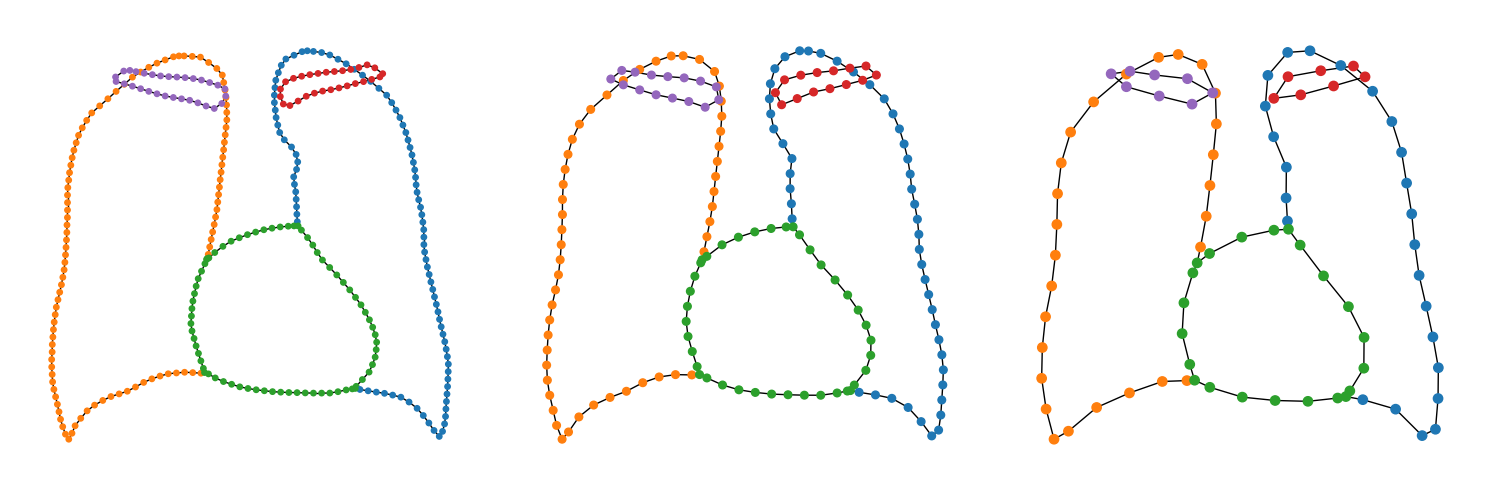

In [8]:
# Visualize each resolution
# colors should follow tab10 with cyan for shared nodes
colors = plt.cm.get_cmap('tab10', 10)
node_sizes = [15, 30, 45]
plt.figure(figsize=(15, 5))
for i, graph in enumerate(graphs):
    plt.subplot(1, len(graphs), i+1)
    pos = nx.get_node_attributes(graph, 'pos')
    
    # Color nodes by organ membership
    node_colors = []
    for node in graph.nodes():
        membership = graph.nodes[node]['organ_membership']
        if '-' in membership:  # Shared node
            node_colors.append(colors(2))
        elif '1' in membership:
            node_colors.append(colors(0))  # tab:blue
        elif '2' in membership:
            node_colors.append(colors(1))  # tab:orange
        elif '3' in membership:
            node_colors.append(colors(2))  # tab:green
        elif '4' in membership:
            node_colors.append(colors(3))  # tab:red
        elif '5' in membership:
            node_colors.append(colors(4))  # tab:purple
    
    nx.draw(graph, pos, node_color=node_colors, node_size=node_sizes[i], with_labels=False)
    #plt.title(f"{config['resolutions'][i].title()}", fontsize=24)
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
plt.tight_layout()
plt.show()